# 06 — Batch Size Sweep：動態 Engine 吞吐調研

**只需 build 一次 dynamic engine**，然後以不同 batch size benchmark，找出最佳批次吞吐配置。

| 步驟 | 內容 |
|------|------|
| 1 | 路徑設定（自動讀取 Phase 1 最佳精度） |
| 2 | Build Dynamic Engine（min/opt/max shapes） |
| 3 | 逐 Batch Benchmark（loadEngine + shapes） |
| 4 | 結果分析（per-image latency、效率曲線） |
| 5 | 視覺化（Latency / QPS / Per-image / Efficiency） |

> **前置條件**：建議先跑完 `05_param_sweep.ipynb`（Phase 1），本 notebook 會自動讀取最佳精度。
> 若 `sweep/sweep_results.csv` 不存在，則預設使用 FP16。

## 1. 路徑設定

In [ ]:
import sys, onnx
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src.env import *
setup_matplotlib()

SWEEP_DIR      = Path("sweep")
SWEEP_CSV      = SWEEP_DIR / "sweep_results.csv"
BATCH_DIR      = SWEEP_DIR / "batch"
BATCH_CSV      = BATCH_DIR / "batch_results.csv"
TIMING_CACHE   = SWEEP_DIR / "timing.cache"
DYNAMIC_ENGINE = BATCH_DIR / "H_dynamic.engine"
BATCH_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZES = [1, 2, 4, 8, 16, 32]

assert TRTEXEC.exists(),    f"trtexec not found: {TRTEXEC}"
assert ONNX_MODEL.exists(), f"ONNX model not found: {ONNX_MODEL}"

USE_FP16 = True  # fallback
if SWEEP_CSV.exists():
    import pandas as pd
    df_prev = pd.read_csv(SWEEP_CSV)
    df_ok   = df_prev[df_prev["success"] == True]
    if not df_ok.empty:
        best     = df_ok.loc[df_ok["mean_ms"].idxmin()]
        USE_FP16 = best["precision"] == "fp16"
        print(f"Phase 1 最佳 config → precision={best['precision']}  "
              f"opt_level={int(best['builder_opt_level'])}  mean_ms={best['mean_ms']:.3f}")
else:
    print("sweep_results.csv 未找到，使用預設 FP16")

model   = onnx.load(str(ONNX_MODEL))
dims    = model.graph.input[0].type.tensor_type.shape.dim
MODEL_C = dims[1].dim_value or 3
MODEL_H = dims[2].dim_value or 448
MODEL_W = dims[3].dim_value or 448
MAX_BATCH = max(BATCH_SIZES)
OPT_BATCH = 4

precision_tag = "fp16" if USE_FP16 else "fp32"
print(f"\n模型輸入 : [N, {MODEL_C}, {MODEL_H}, {MODEL_W}]")
print(f"精度     : {precision_tag}")
print(f"Batch    : {BATCH_SIZES}")
print(f"Dynamic engine → {DYNAMIC_ENGINE}")

## 2. Build Dynamic Engine

用 `--minShapes / --optShapes / --maxShapes` 建立支援 batch 1–32 的動態 engine。

| Shape 參數 | 意義 | 本 notebook 設定 |
|-----------|------|-----------------|
| `minShapes` | engine 支援的最小輸入 | batch = 1 |
| `optShapes` | TensorRT 針對此 shape 做最佳化 | batch = 4 |
| `maxShapes` | engine 支援的最大輸入 | batch = 32 |

> `optShapes` 的 batch 對齊你的**最常見推論批次**，kernel 選擇效果最好。
> 本 notebook 預設 opt=4，可在 Cell 1 的 `OPT_BATCH` 修改。

In [4]:
import subprocess, time, onnx as _onnx

# ── 產生動態 batch 的 ONNX（原始模型 batch dim 為靜態，trtexec 需要動態軸）──
DYNAMIC_ONNX = BATCH_DIR / "H_dynamic.onnx"

if not DYNAMIC_ONNX.exists():
    model_dyn = _onnx.load(str(ONNX_MODEL))
    # 將第 0 個輸入的 batch dim 改為符號（動態）
    for inp in model_dyn.graph.input:
        d = inp.type.tensor_type.shape.dim[0]
        d.ClearField("dim_value")
        d.dim_param = "batch_size"
    # 同樣修改輸出，避免 TRT 型別推斷失敗
    for out in model_dyn.graph.output:
        if out.type.HasField("tensor_type") and out.type.tensor_type.HasField("shape"):
            d = out.type.tensor_type.shape.dim[0]
            d.ClearField("dim_value")
            d.dim_param = "batch_size"
    _onnx.save(model_dyn, str(DYNAMIC_ONNX))
    print(f"Dynamic ONNX saved → {DYNAMIC_ONNX}")
else:
    print(f"Dynamic ONNX 已存在：{DYNAMIC_ONNX}")


def shape_str(batch):
    return f"images:{batch}x{MODEL_C}x{MODEL_H}x{MODEL_W}"


if DYNAMIC_ENGINE.exists():
    print(f"Dynamic engine 已存在：{DYNAMIC_ENGINE}")
    print("（如需重新 build，刪除後重跑本格）")
else:
    cmd = [
        str(TRTEXEC),
        f"--onnx={DYNAMIC_ONNX}",
        f"--saveEngine={DYNAMIC_ENGINE}",
        f"--minShapes={shape_str(1)}",
        f"--optShapes={shape_str(OPT_BATCH)}",
        f"--maxShapes={shape_str(MAX_BATCH)}",
        f"--warmUp={WARMUP_MS}",
        f"--timingCacheFile={TIMING_CACHE}",
        "--skipInference",
    ]
    if USE_FP16:
        cmd.append("--fp16")

    print(f"Building dynamic {precision_tag} engine ...")
    print(f"  min={shape_str(1)}")
    print(f"  opt={shape_str(OPT_BATCH)}")
    print(f"  max={shape_str(MAX_BATCH)}\n")

    t0      = time.time()
    proc    = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0

    if proc.returncode != 0:
        print("=== STDERR ===")
        print(proc.stderr[-3000:])
    else:
        for line in proc.stdout.splitlines():
            if any(kw in line for kw in ["[I]", "[W]", "[E]", "Saving"]):
                print(line)
        print(f"\nBuild 完成  elapsed={elapsed:.1f}s  engine={DYNAMIC_ENGINE}")

if DYNAMIC_ENGINE.exists():
    print(f"\nEngine exists: {DYNAMIC_ENGINE}  ({DYNAMIC_ENGINE.stat().st_size // 1024} KB)")
else:
    print(f"\nEngine build FAILED — engine file not found")

Dynamic ONNX saved → sweep\batch\H_dynamic.onnx
Building dynamic fp16 engine ...
  min=images:1x3x448x448
  opt=images:4x3x448x448
  max=images:32x3x448x448

[05/27/2026-09:03:28] [I] === Model Options ===
[05/27/2026-09:03:28] [I] Format: ONNX
[05/27/2026-09:03:28] [I] Model: sweep\batch\H_dynamic.onnx
[05/27/2026-09:03:28] [I] Output:
[05/27/2026-09:03:28] [I] === Build Options ===
[05/27/2026-09:03:28] [I] Memory Pools: workspace: default, dlaSRAM: default, dlaLocalDRAM: default, dlaGlobalDRAM: default, tacticSharedMem: default
[05/27/2026-09:03:28] [I] avgTiming: 8
[05/27/2026-09:03:28] [I] Precision: FP32+FP16
[05/27/2026-09:03:28] [I] LayerPrecisions: 
[05/27/2026-09:03:28] [I] Layer Device Types: 
[05/27/2026-09:03:28] [I] Calibration: 
[05/27/2026-09:03:28] [I] Refit: Disabled
[05/27/2026-09:03:28] [I] Strip weights: Disabled
[05/27/2026-09:03:28] [I] Version Compatible: Disabled
[05/27/2026-09:03:28] [I] ONNX Plugin InstanceNorm: Disabled
[05/27/2026-09:03:28] [I] TensorRT run

## 3. 逐 Batch Benchmark

用 `--loadEngine`（不重新 build）搭配 `--shapes` 指定本次推論的 batch，逐一量測。

結果逐批寫入 `sweep/batch/batch_results.csv`，可中斷後續跑。

In [5]:
import re, pandas as pd
from tqdm.auto import tqdm

def parse_trtexec(stdout: str) -> dict:
    patterns = {
        "mean_ms":        r"mean\s*=\s*([\d.]+)\s*ms",
        "median_ms":      r"median\s*=\s*([\d.]+)\s*ms",
        "p95_ms":         r"95th percentile.*?=\s*([\d.]+)\s*ms",
        "p99_ms":         r"99th percentile.*?=\s*([\d.]+)\s*ms",
        "throughput_qps": r"Throughput:\s*([\d.]+)\s*qps",
        "gpu_compute_ms": r"GPU Compute Time.*?mean\s*=\s*([\d.]+)\s*ms",
    }
    return {
        k: float(m.group(1))
        for k, pat in patterns.items()
        if (m := re.search(pat, stdout, re.IGNORECASE))
    }


# Resume
if BATCH_CSV.exists():
    df_done   = pd.read_csv(BATCH_CSV)
    done_bs   = set(df_done["batch_size"].astype(int))
    results   = df_done.to_dict("records")
    print(f"Resuming: {done_bs} done")
else:
    done_bs = set()
    results = []

for bs in tqdm(BATCH_SIZES, desc="Batch sweep"):
    if bs in done_bs:
        continue

    cmd = [
        str(TRTEXEC),
        f"--loadEngine={DYNAMIC_ENGINE}",
        f"--shapes={shape_str(bs)}",
        f"--warmUp={WARMUP_MS}",
        f"--duration={DURATION_S}",
    ]

    t0   = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0

    rec = {"batch_size": bs, "run_time_s": round(elapsed, 1), "success": proc.returncode == 0}
    if proc.returncode == 0:
        m = parse_trtexec(proc.stdout)
        rec.update(m)
        # per-image latency 和 有效 QPS（以圖片數計）
        if "mean_ms" in m:
            rec["per_image_ms"]  = m["mean_ms"] / bs
            rec["images_per_s"]  = m.get("throughput_qps", float("nan")) * bs
        print(f"  batch={bs:>2}  mean={rec.get('mean_ms', float('nan')):.3f}ms  "
              f"per-img={rec.get('per_image_ms', float('nan')):.3f}ms  "
              f"img/s={rec.get('images_per_s', float('nan')):.1f}")
    else:
        print(f"  batch={bs:>2}  FAILED")
        rec["error"] = proc.stderr[-300:].strip()

    results.append(rec)
    pd.DataFrame(results).to_csv(BATCH_CSV, index=False)

df = pd.DataFrame(results)
print(f"\nBatch sweep complete → {BATCH_CSV}")

d:\tensorrt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batch sweep:  17%|█▋        | 1/6 [00:10<00:54, 10.96s/it]

  batch= 1  mean=1.340ms  per-img=1.340ms  img/s=685.4


Batch sweep:  33%|███▎      | 2/6 [00:21<00:43, 10.92s/it]

  batch= 2  mean=2.366ms  per-img=1.183ms  img/s=802.3


Batch sweep:  50%|█████     | 3/6 [00:32<00:32, 10.91s/it]

...

  batch= 8  mean=9.488ms  per-img=1.186ms  img/s=829.3


Batch sweep:  83%|████████▎ | 5/6 [00:54<00:10, 10.98s/it]

  batch=16  mean=18.944ms  per-img=1.184ms  img/s=834.8


Batch sweep: 100%|██████████| 6/6 [01:06<00:00, 11.04s/it]

  batch=32  mean=38.102ms  per-img=1.191ms  img/s=828.5

Batch sweep complete → sweep\batch\batch_results.csv


## 4. 結果分析

三個關鍵指標：

| 指標 | 意義 | 場景 |
|------|------|------|
| `mean_ms` | 一個 batch 的端對端延遲 | 低延遲場景 |
| `per_image_ms` | 每張圖平均時間 = mean_ms / batch | 比較批次效率 |
| `images_per_s` | 每秒處理張數 = QPS × batch | 吞吐量場景 |

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(BATCH_CSV)
df_ok = df[df["success"] == True].copy()
df_ok["batch_size"] = df_ok["batch_size"].astype(int)
df_ok = df_ok.sort_values("batch_size")

# 相對指標
base_per_img = df_ok.loc[df_ok["batch_size"] == 1, "per_image_ms"].values[0]
df_ok["efficiency"] = base_per_img / df_ok["per_image_ms"]  # 1.0 = 與 batch=1 相同效率，越高越好
df_ok["latency_x"]  = df_ok["mean_ms"] / df_ok.loc[df_ok["batch_size"] == 1, "mean_ms"].values[0]

cols = ["batch_size", "mean_ms", "per_image_ms", "images_per_s", "gpu_compute_ms", "efficiency"]
avail = [c for c in cols if c in df_ok.columns]
print(df_ok[avail].to_string(index=False, float_format="{:.3f}".format))

# 找最佳 batch（images_per_s 最高）
best_thr = df_ok.loc[df_ok["images_per_s"].idxmax()]
best_lat = df_ok.loc[df_ok["batch_size"] == 1]
print(f"\n最低延遲  : batch=1   mean={best_lat['mean_ms'].values[0]:.3f}ms")
print(f"最高吞吐量: batch={int(best_thr['batch_size'])}   "
      f"images/s={best_thr['images_per_s']:.1f}  "
      f"per-img={best_thr['per_image_ms']:.3f}ms")

# 效率拐點：efficiency 開始下降的 batch size
eff = df_ok["efficiency"].values
bs  = df_ok["batch_size"].values
knee_idx = np.argmax(eff)   # efficiency 最高點（通常是 batch 增大後 plateau 的起點）
print(f"\n效率最高點: batch={bs[knee_idx]}  efficiency={eff[knee_idx]:.3f}×")
print("（超過此點繼續加大 batch，per-image latency 不再下降）")

 batch_size  mean_ms  per_image_ms  images_per_s  gpu_compute_ms  efficiency
          1    1.340         1.340       685.407           1.230       1.000
          2    2.366         1.183       802.256           2.158       1.132
          4    4.525         1.131       858.828           4.122       1.184
          8    9.488         1.186       829.272           8.635       1.130
         16   18.944         1.184       834.765          17.301       1.131
         32   38.102         1.191       828.458          34.849       1.125

最低延遲  : batch=1   mean=1.340ms
最高吞吐量: batch=4   images/s=858.8  per-img=1.131ms

效率最高點: batch=4  efficiency=1.184×
（超過此點繼續加大 batch，per-image latency 不再下降）


## 5. 視覺化

四張圖：
1. **Batch Latency**：batch size vs mean_ms（延遲隨 batch 增加的幅度）
2. **Throughput**：batch size vs images/s（吞吐量甜蜜點）
3. **Per-image Latency**：每張圖平均耗時（看批次化的邊際效益）
4. **Batching Efficiency**：效率曲線（1.0 = batch=1 的效率基線）

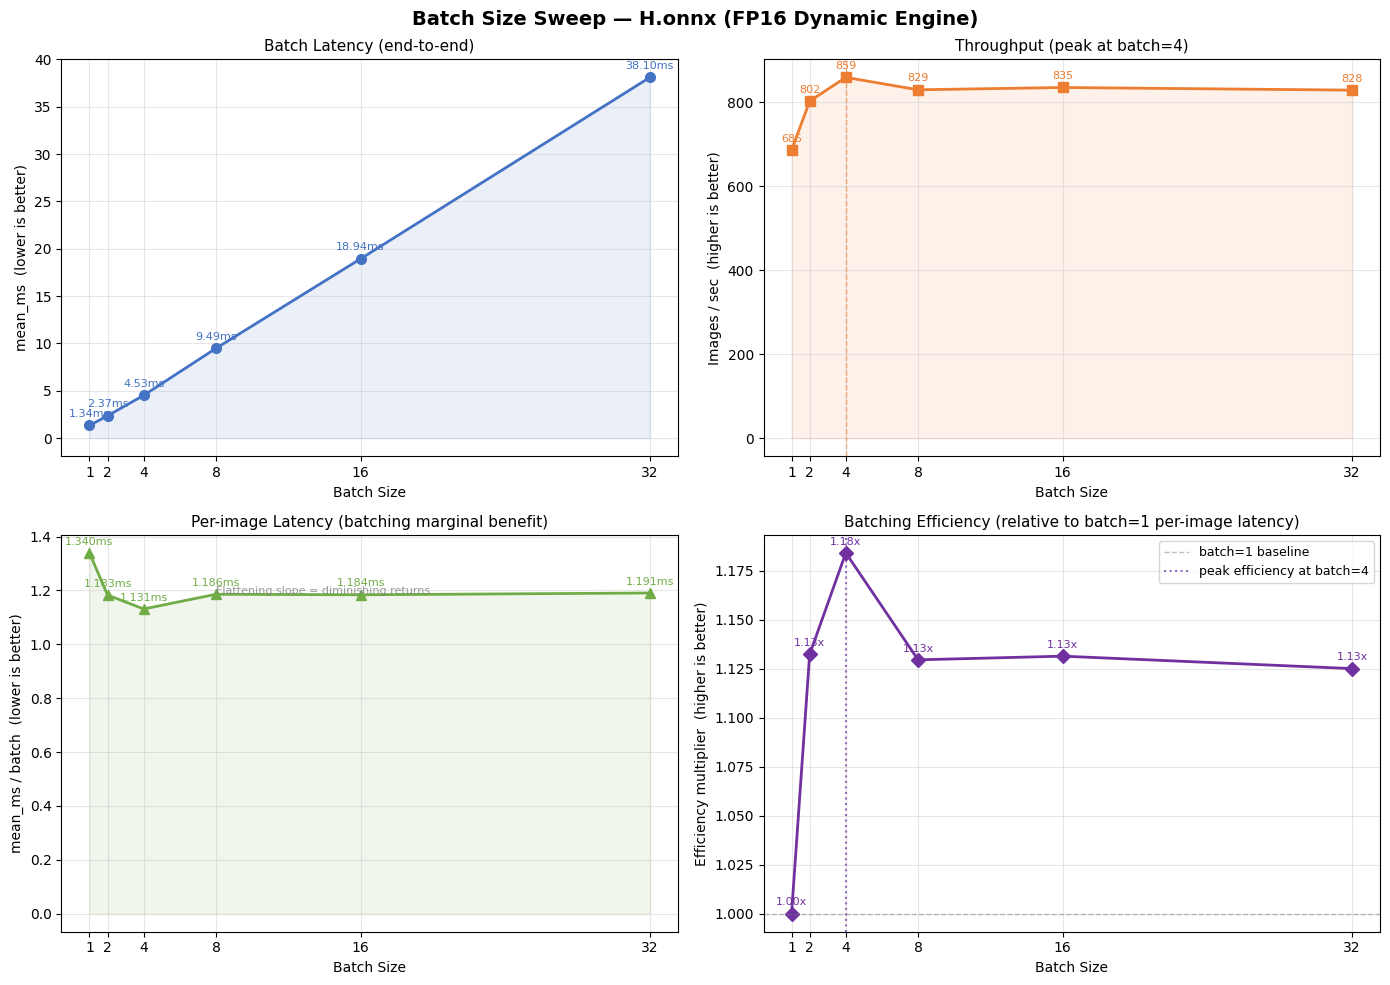

Saved -> sweep\batch\batch_sweep_results.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

bs_vals   = df_ok["batch_size"].values
lat_vals  = df_ok["mean_ms"].values
thr_vals  = df_ok["images_per_s"].values
pimg_vals = df_ok["per_image_ms"].values
eff_vals  = df_ok["efficiency"].values

BLUE   = "#4472C4"
ORANGE = "#ED7D31"
GREEN  = "#70AD47"
PURPLE = "#7030A0"

def annotate_line(ax, x, y, fmt="{:.2f}", color="black", offset=(0, 6)):
    for xi, yi in zip(x, y):
        ax.annotate(fmt.format(yi), (xi, yi),
                    xytext=offset, textcoords="offset points",
                    fontsize=8, ha="center", color=color)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 1. Batch latency ─────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(bs_vals, lat_vals, marker="o", color=BLUE, linewidth=2, markersize=7)
ax.fill_between(bs_vals, lat_vals, alpha=0.1, color=BLUE)
annotate_line(ax, bs_vals, lat_vals, fmt="{:.2f}ms", color=BLUE)
ax.set_title("Batch Latency (end-to-end)", fontsize=11)
ax.set_xlabel("Batch Size")
ax.set_ylabel("mean_ms  (lower is better)")
ax.set_xticks(bs_vals)
ax.grid(alpha=0.3)

# ── 2. Throughput ─────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(bs_vals, thr_vals, marker="s", color=ORANGE, linewidth=2, markersize=7)
ax.fill_between(bs_vals, thr_vals, alpha=0.1, color=ORANGE)
annotate_line(ax, bs_vals, thr_vals, fmt="{:.0f}", color=ORANGE)
best_bs = bs_vals[np.argmax(thr_vals)]
ax.axvline(best_bs, color=ORANGE, linestyle="--", linewidth=1, alpha=0.6)
ax.set_title(f"Throughput (peak at batch={best_bs})", fontsize=11)
ax.set_xlabel("Batch Size")
ax.set_ylabel("Images / sec  (higher is better)")
ax.set_xticks(bs_vals)
ax.grid(alpha=0.3)

# ── 3. Per-image latency ──────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(bs_vals, pimg_vals, marker="^", color=GREEN, linewidth=2, markersize=7)
ax.fill_between(bs_vals, pimg_vals, alpha=0.1, color=GREEN)
annotate_line(ax, bs_vals, pimg_vals, fmt="{:.3f}ms", color=GREEN)
ax.set_title("Per-image Latency (batching marginal benefit)", fontsize=11)
ax.set_xlabel("Batch Size")
ax.set_ylabel("mean_ms / batch  (lower is better)")
ax.set_xticks(bs_vals)
ax.grid(alpha=0.3)
ax.annotate("Flattening slope = diminishing returns",
            xy=(bs_vals[len(bs_vals)//2], pimg_vals[len(bs_vals)//2]),
            fontsize=8, color="gray", alpha=0.8)

# ── 4. Batching efficiency ────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(bs_vals, eff_vals, marker="D", color=PURPLE, linewidth=2, markersize=7)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, alpha=0.5, label="batch=1 baseline")
knee_bs = bs_vals[np.argmax(eff_vals)]
ax.axvline(knee_bs, color=PURPLE, linestyle=":", linewidth=1.5, alpha=0.7,
           label=f"peak efficiency at batch={knee_bs}")
annotate_line(ax, bs_vals, eff_vals, fmt="{:.2f}x", color=PURPLE)
ax.set_title("Batching Efficiency (relative to batch=1 per-image latency)", fontsize=11)
ax.set_xlabel("Batch Size")
ax.set_ylabel("Efficiency multiplier  (higher is better)")
ax.set_xticks(bs_vals)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

precision_label = "FP16" if USE_FP16 else "FP32"
plt.suptitle(f"Batch Size Sweep — H.onnx ({precision_label} Dynamic Engine)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

out_png = BATCH_DIR / "batch_sweep_results.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")